In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [189]:
df = pd.read_csv("data/player_data_COMPLETE.csv")

Filtramos para que nos salgan únicamente los jugadores de la posición que queremos

In [190]:
df_w = df[df["main_position"] == "GK"].copy()
df_clustering = df_w[df_w["low_minutes_flag"] == False].copy()

Selección de métricas

In [191]:
features_clustering = [
    "gk_aerial_duels_avg",
    "xg_save_avg",
    "prevented_goals_avg",
    "accurate_pass_avg",
    "save_percent",
    "accurate_progressive_pass_avg"
]

X = df_clustering[features_clustering].fillna(0)

Escalado

In [192]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [193]:
df_scaled = pd.DataFrame(X_scaled, columns=features_clustering)
print("\nDatos estandarizados:")
print(df_scaled.head())


Datos estandarizados:
   gk_aerial_duels_avg  xg_save_avg  prevented_goals_avg  accurate_pass_avg  \
0            -0.397885    -0.950427            -1.099031          -0.736730   
1            -1.210700     0.023117             0.184096           2.788321   
2             1.075343    -0.034150            -2.846167           0.120660   
3            -1.515506    -0.148685            -2.041253           1.355645   
4            -1.261501    -1.036328             0.884845          -0.323205   

   save_percent  accurate_progressive_pass_avg  
0     -1.238548                      -0.645811  
1      0.130343                      -0.289936  
2     -1.563602                       0.704824  
3     -2.045843                      -0.090261  
4      1.377149                      -0.912971  


PCA: Reducción de dimensionalidad

In [194]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.31634092 0.22859949 0.1980214 ]


In [195]:
n_components = 3
pca_clustering = pd.DataFrame(data=X_pca, columns=[f'PC{i}' for i in range(1, n_components+1)])
print("\nComponentes principales:")
print(pca_clustering.head())


Componentes principales:
        PC1       PC2       PC3
0  1.251082 -1.579641  0.250205
1  0.197413  0.948852  2.186850
2  2.772508  0.253116 -0.376313
3  3.060897 -0.393300  1.556366
4 -1.640969 -1.253958  1.109781


C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the

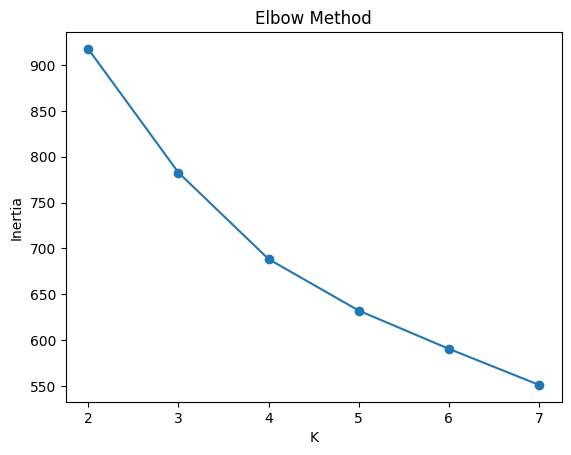

In [196]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [197]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_clustering["cb_cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [198]:
cluster_profile = df_clustering.groupby("cb_cluster")[features_clustering].mean()
print(cluster_profile)

            gk_aerial_duels_avg  xg_save_avg  prevented_goals_avg  \
cb_cluster                                                          
0                      0.395806     1.570000            -0.328323   
1                      0.508627     1.310973             0.075111   
2                      0.302470     1.064687             0.050949   
3                      0.278560     1.106927            -0.165228   

            accurate_pass_avg  save_percent  accurate_progressive_pass_avg  
cb_cluster                                                                  
0                   22.014573     58.814839                       6.431092  
1                   17.111767     70.823589                       4.293752  
2                   26.239397     71.845654                       5.053243  
3                   16.932349     64.070822                       3.206173  


In [199]:
cols_show = ["name", "market_value", "minutes_on_field", "cb_cluster"]

df_cb_view = df_clustering[cols_show].sort_values(
    ["cb_cluster", "market_value"],
    ascending=[True, False]
)

for c in sorted(df_clustering["cb_cluster"].unique()):
    print(f"\n--- CLUSTER {c} ---")
    display(df_cb_view[df_cb_view["cb_cluster"] == c].head(10))


--- CLUSTER 0 ---


,name,market_value,minutes_on_field,cb_cluster
3346,A. Ramsdale,25000000.0,2130,0
1734,D. Ramaj,18000000.0,1081,0
3243,K. Grabara,12000000.0,2851,0
1652,N. Atubolu,10000000.0,2815,0
2186,S. Johnstone,10000000.0,1000,0
3015,A. Bayındır,10000000.0,1008,0
3550,M. Hermansen,9000000.0,1938,0
3757,S. Turati,7000000.0,2099,0
2807,J. Omlin,6000000.0,770,0
1433,J. Urbig,4000000.0,878,0



--- CLUSTER 1 ---


,name,market_value,minutes_on_field,cb_cluster
2781,G. Vicario,35000000.0,2387,1
2884,Unai Simón,30000000.0,3321,1
3831,A. Trubin,25000000.0,1960,1
3439,Robert Sánchez,20000000.0,3216,1
3482,M. Bułka,20000000.0,2288,1
2297,N. Pope,16000000.0,2905,1
3578,M. Carnesecchi,16000000.0,3296,1
1927,B. Leno,13000000.0,3918,1
2200,Kepa Arrizabalaga,12000000.0,2389,1
2665,D. Henderson,12000000.0,3880,1



--- CLUSTER 2 ---


,name,market_value,minutes_on_field,cb_cluster
2929,Diogo Costa,45000000.0,3074,2
2785,G. Kobel,40000000.0,3263,2
2274,M. Maignan,38000000.0,3425,2
2744,David Raya,35000000.0,3793,2
1929,E. Martínez,28000000.0,3474,2
2080,J. Pickford,22000000.0,3779,2
3546,D. Petrović,20000000.0,3486,2
2514,I. Provedel,14000000.0,2822,2
2363,M. Flekken,12000000.0,3725,2
2691,A. Meret,12000000.0,2829,2



--- CLUSTER 3 ---


,name,market_value,minutes_on_field,cb_cluster
3544,G. Mamardashvili,45000000.0,2797,3
2946,G. Donnarumma,40000000.0,2476,3
1877,T. Courtois,28000000.0,3358,3
1891,J. Oblak,28000000.0,3580,3
1926,M. ter Stegen,28000000.0,653,3
1932,Alisson,28000000.0,2906,3
2434,Álex Remiro,25000000.0,3540,3
1450,F. Jörgensen,20000000.0,705,3
2906,C. Kelleher,20000000.0,1718,3
1079,B. Verbruggen,18000000.0,3950,3


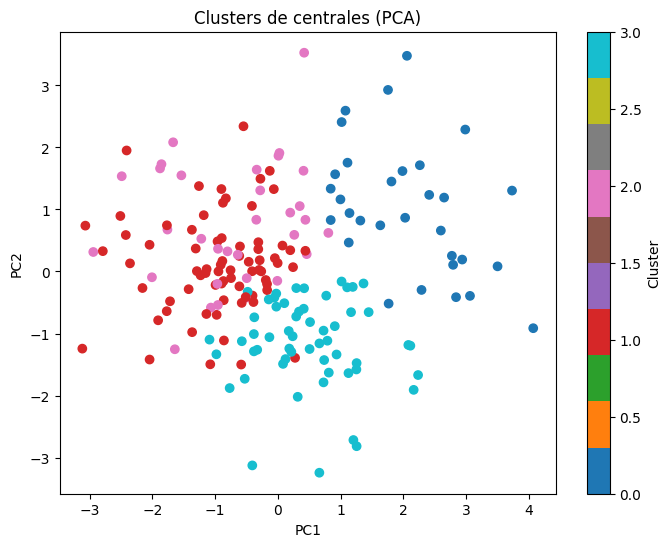

In [200]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clustering["cb_cluster"],
    cmap="tab10"
)

plt.title("Clusters de centrales (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

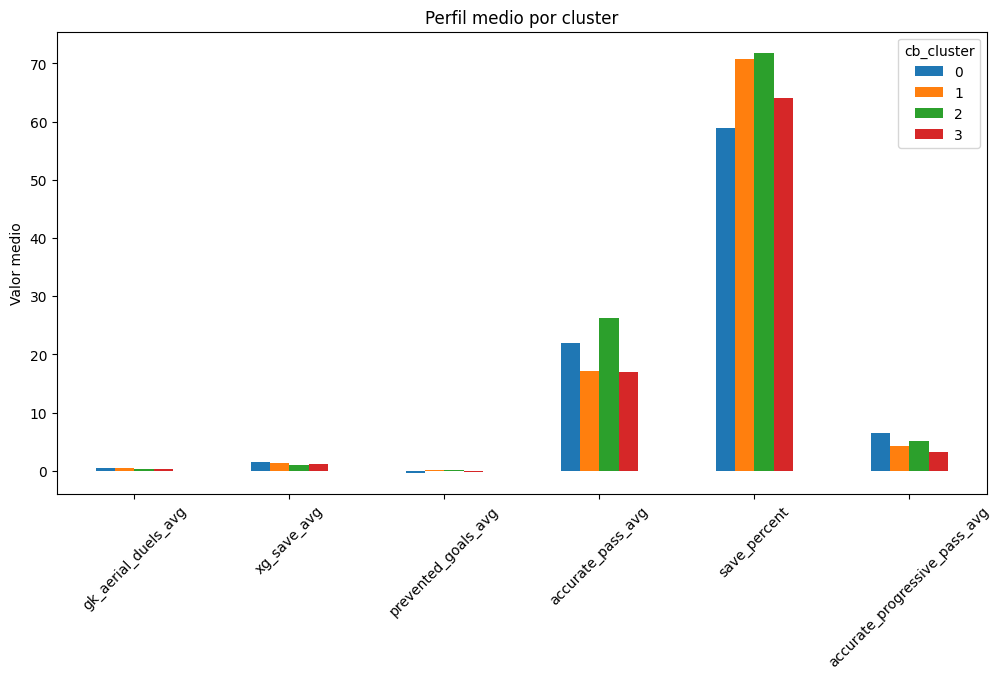

In [201]:
cluster_profile.T.plot(kind="bar", figsize=(12,6))
plt.title("Perfil medio por cluster")
plt.xticks(rotation=45)
plt.ylabel("Valor medio")
plt.show()

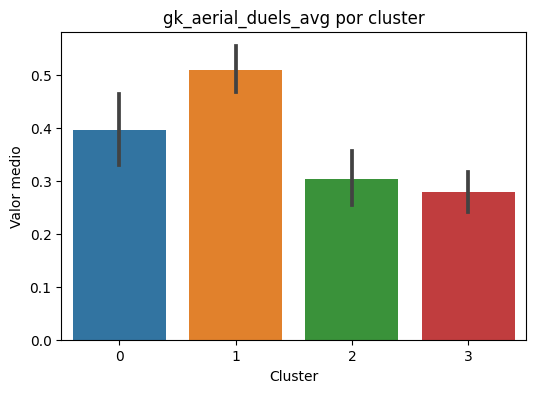

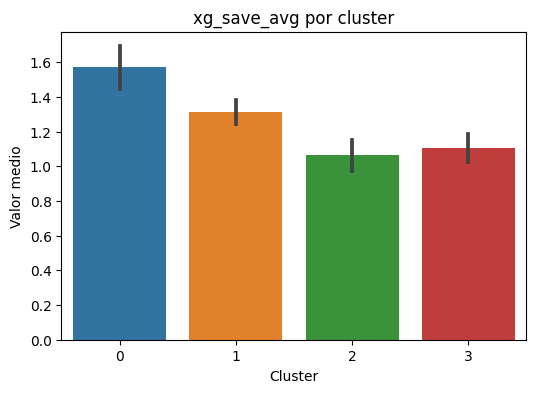

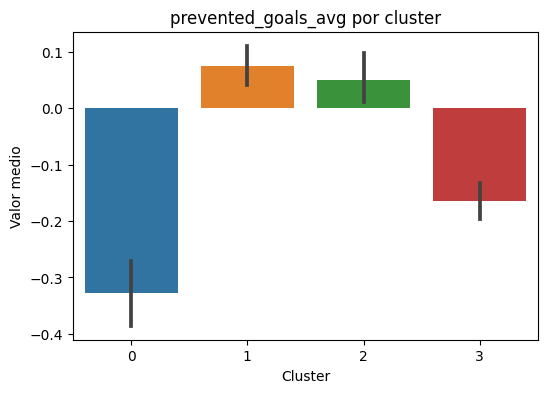

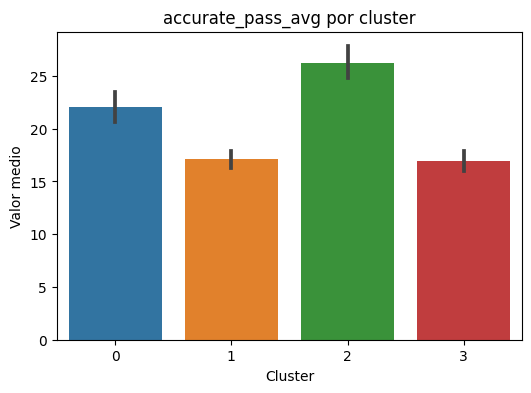

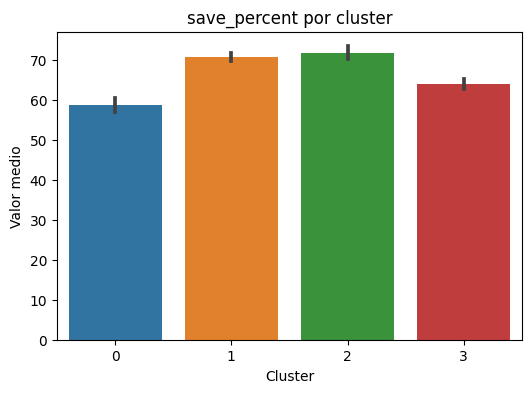

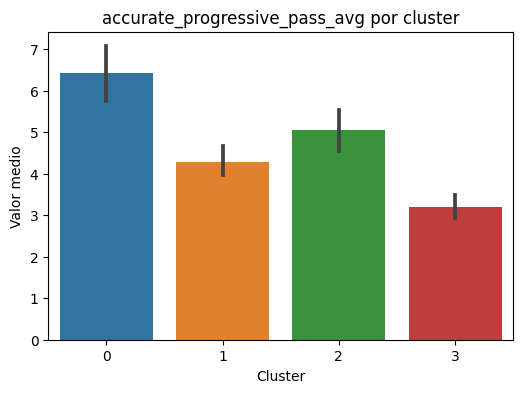

In [202]:
for col in features_clustering:
    
    plt.figure(figsize=(6,4))
    
    sns.barplot(
        x="cb_cluster",
        y=col,
        data=df_clustering
    )
    
    plt.title(f"{col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Valor medio")
    
    plt.show()

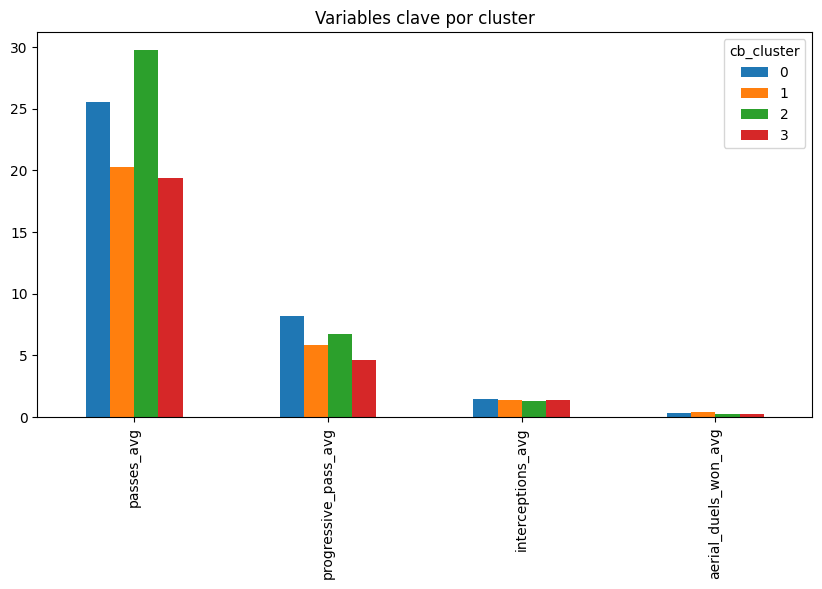

In [203]:
key_vars = [
    "passes_avg",
    "progressive_pass_avg",
    "interceptions_avg",
    "aerial_duels_won_avg"
]

df_clustering.groupby("cb_cluster")[key_vars].mean().T.plot(kind="bar", figsize=(10,5))
plt.title("Variables clave por cluster")
plt.show()

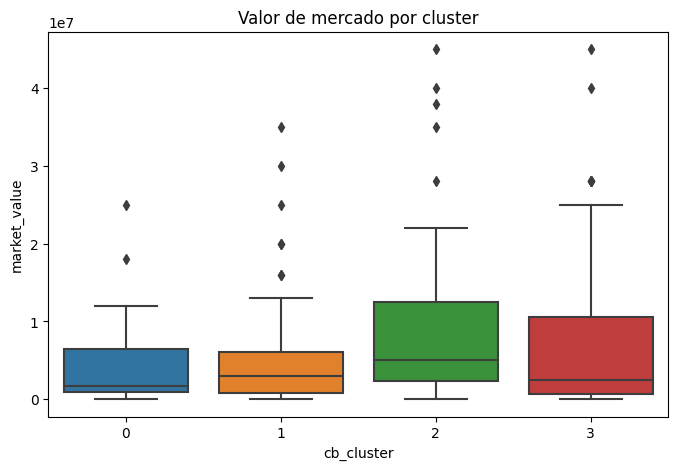

In [204]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cb_cluster", y="market_value", data=df_clustering)
plt.title("Valor de mercado por cluster")
plt.show()

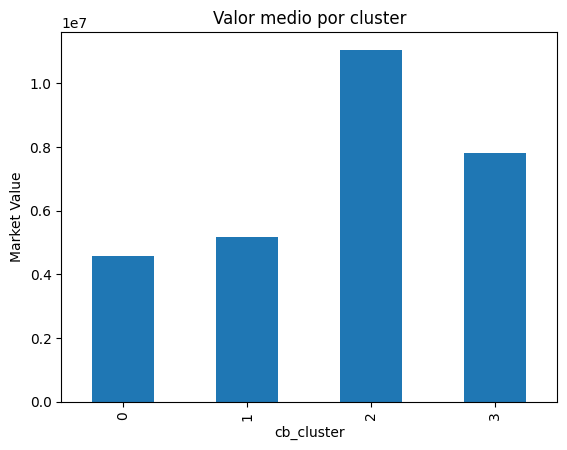

In [205]:
df_clustering.groupby("cb_cluster")["market_value"].mean().plot(kind="bar")

plt.title("Valor medio por cluster")
plt.ylabel("Market Value")
plt.show()

In [206]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features_clustering,
    index=["PC1", "PC2", "PC3"]
)

display(loadings)

,gk_aerial_duels_avg,xg_save_avg,prevented_goals_avg,accurate_pass_avg,save_percent,accurate_progressive_pass_avg
PC1,-0.216765,0.219380,-0.637986,0.067674,-0.678184,0.182611
PC2,0.302404,0.338722,0.159016,0.525661,0.102655,0.694028
PC3,-0.512347,-0.618304,-0.066960,0.575525,0.107992,0.088469


gk_labels = {
    0: "Low-performing GK",
    1: "Shot-stopper GK",
    2: "Ball-playing GK",
    3: "Low-impact GK"
}

In [207]:
cb_labels = {
    0: "Ball-stealing CB",
    1: "Ball-playing CB",
    2: "Aerial dominant CB",
    3: "Low-impact CB"
}

fb_labels = {
    0: "Attacking full-back",
    1: "Creative full-back",
    2: "Low-impact full-back",
    3: "Defensive full-back"
}

mf_labels = {
    0: "Attacking midfielder",
    1: "Low-impact midfielder",
    2: "Deep-lying playmaker",
    3: "Ball-winning midfielder"
}

w_labels = {
    0: "Dribbler winger",
    1: "Low-impact winger",
    2: "Defensive winger",
    3: "Goal-scoring winger"
}

fw_labels = {
    0: "Target man",
    1: "Pressing forward",
    2: "Creative forward",
    3: "Poacher"
}

gk_labels = {
    0: "Low-performing GK",
    1: "Ball-playing GK",
    2: "Elite GK",
    3: "Overrated ball-playing GK"
}

def assign_role(row):
  
    return gk_labels.get(row["cb_cluster"])


df_clustering["player_role"] = df_clustering.apply(assign_role, axis=1)

In [208]:
df_clustering[["id", "name", "cb_cluster", "player_role"]].to_csv("clustering/data/gk_clusters.csv", index=False)